In [1]:
# ============================================================
# ABLATION 1: WEIGHTED vs UNWEIGHTED LOSS
# ============================================================
# CELL 1: CONFIG
import os, time, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

USE_WEIGHTED_LOSS = True   # <-- toggle this: True = weighted (your main method), False = ablation (unweighted)

RUN_TAG = f"custom_cnn_{'weighted' if USE_WEIGHTED_LOSS else 'unweighted'}_loss_ablation"
SAVE_DIR = os.path.join("checkpoints", RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "last_checkpoint.pth")
BEST_PATH = os.path.join(SAVE_DIR, "best_model.pth")
RESULTS_PATH = os.path.join(SAVE_DIR, "results.json")
CURVES_PATH = os.path.join(SAVE_DIR, "curves.png")
HISTORY_PATH = os.path.join(SAVE_DIR, "history.json")

In [2]:
# ============================================================
# ABLATION 1: WEIGHTED vs UNWEIGHTED LOSS
# ============================================================
# CELL 1: CONFIG
import os, time, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LR = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

USE_WEIGHTED_LOSS = True   # <-- toggle this: True = weighted (your main method), False = ablation (unweighted)

RUN_TAG = f"wider_cnn_full"
SAVE_DIR = os.path.join("checkpoints", RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "last_checkpoint.pth")
BEST_PATH = os.path.join(SAVE_DIR, "best_model.pth")
RESULTS_PATH = os.path.join(SAVE_DIR, "results.json")
CURVES_PATH = os.path.join(SAVE_DIR, "curves.png")
HISTORY_PATH = os.path.join(SAVE_DIR, "history.json")

In [3]:
# CELL 2: TRANSFORMS
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
# CELL 3: LOAD DATA
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_ds.classes)
class_names = train_ds.classes
print(f"Classes ({NUM_CLASSES}): {class_names}")
assert train_ds.classes == val_ds.classes == test_ds.classes

Classes (16): ['Aloe Vera Disease', 'Aloe Vera Dried', 'Aloe Vera Mature Healthy', 'Aloe Vera Young Healthy', 'Azadirachta Indica Chlorotic', 'Azadirachta Indica Disease', 'Azadirachta Indica Healthy', 'Hibiscus Rosa Sinensis Chlorotic', 'Hibiscus Rosa Sinensis Disease', 'Hibiscus Rosa Sinensis Healthy', 'Kalanchoe Pinnata Chlorotic', 'Kalanchoe Pinnata Disease', 'Kalanchoe Pinnata Healthy', 'Piper Betle Chlorotic', 'Piper Betle Disease', 'Piper Betle Healthy']


In [5]:
# CELL 4: CLASS WEIGHTS (computed regardless, but only applied if USE_WEIGHTED_LOSS)
class_counts = np.bincount([label for _, label in train_ds.samples])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

if USE_WEIGHTED_LOSS:
    print("Using WEIGHTED cross-entropy loss")
    loss_weight_arg = class_weights
else:
    print("Using UNWEIGHTED cross-entropy loss (ablation)")
    loss_weight_arg = None

Using WEIGHTED cross-entropy loss


In [6]:
# ============================================================
# ABLATION 3: LIGHTWEIGHT CNN (32→64→128) vs WIDER CNN (64→128→256)
# ============================================================
# Same Cells 1-4, 6-11 as above (with USE_WEIGHTED_LOSS = True, your main setting)
# Only CELL 5 (model definition) changes:

# CELL 5 (WIDER VARIANT):
class WiderCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

model = WiderCNN(NUM_CLASSES).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {num_params:,} (~{num_params/1e6:.3f}M)")

Total params: 375,824 (~0.376M)


In [7]:
# CELL 6: LOSS / OPTIMIZER
criterion = nn.CrossEntropyLoss(weight=loss_weight_arg)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [8]:
# CELL 7: EPOCH RUNNER
def run_epoch(loader, train=True, desc="Epoch"):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    context = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False)
    with context:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, precision, recall

In [9]:
# CELL 8: CHECKPOINT RESUME
start_epoch = 1
best_val_f1 = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_f1 = ckpt["best_val_f1"]
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    print(f"Resumed at epoch {start_epoch}, best_val_f1={best_val_f1:.4f}")

In [10]:
# CELL 9: TRAINING LOOP
for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True, desc=f"Epoch {epoch}/{EPOCHS} [train]")
    val_loss, val_acc, val_f1, val_prec, val_rec = run_epoch(val_loader, train=False, desc=f"Epoch {epoch}/{EPOCHS} [val]")
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"[{RUN_TAG}] Epoch {epoch}/{EPOCHS} | Train acc {train_acc:.4f} f1 {train_f1:.4f} | "
          f"Val acc {val_acc:.4f} f1 {val_f1:.4f} | LR {optimizer.param_groups[0]['lr']:.6f}", flush=True)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> New best model saved (val macro-F1={val_f1:.4f})", flush=True)

    torch.save({
        "epoch": epoch, "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(), "scheduler_state": scheduler.state_dict(),
        "best_val_f1": best_val_f1,
    }, CKPT_PATH)

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

[wider_cnn_full] Epoch 1/30 | Train acc 0.2175 f1 0.1866 | Val acc 0.2060 f1 0.1803 | LR 0.000299
  -> New best model saved (val macro-F1=0.1803)


[wider_cnn_full] Epoch 2/30 | Train acc 0.3734 f1 0.3443 | Val acc 0.4221 f1 0.3876 | LR 0.000297
  -> New best model saved (val macro-F1=0.3876)


[wider_cnn_full] Epoch 3/30 | Train acc 0.4697 f1 0.4337 | Val acc 0.3618 f1 0.3450 | LR 0.000293


[wider_cnn_full] Epoch 4/30 | Train acc 0.5032 f1 0.4747 | Val acc 0.3920 f1 0.3249 | LR 0.000287


[wider_cnn_full] Epoch 5/30 | Train acc 0.5552 f1 0.5257 | Val acc 0.4171 f1 0.3525 | LR 0.000280


...

[wider_cnn_full] Epoch 26/30 | Train acc 0.7608 f1 0.7518 | Val acc 0.8090 f1 0.7984 | LR 0.000013


[wider_cnn_full] Epoch 27/30 | Train acc 0.7543 f1 0.7492 | Val acc 0.8141 f1 0.8023 | LR 0.000007
  -> New best model saved (val macro-F1=0.8023)


[wider_cnn_full] Epoch 28/30 | Train acc 0.7532 f1 0.7453 | Val acc 0.7990 f1 0.7836 | LR 0.000003


[wider_cnn_full] Epoch 29/30 | Train acc 0.7695 f1 0.7665 | Val acc 0.7990 f1 0.7850 | LR 0.000001


[wider_cnn_full] Epoch 30/30 | Train acc 0.7587 f1 0.7440 | Val acc 0.8040 f1 0.7938 | LR 0.000000


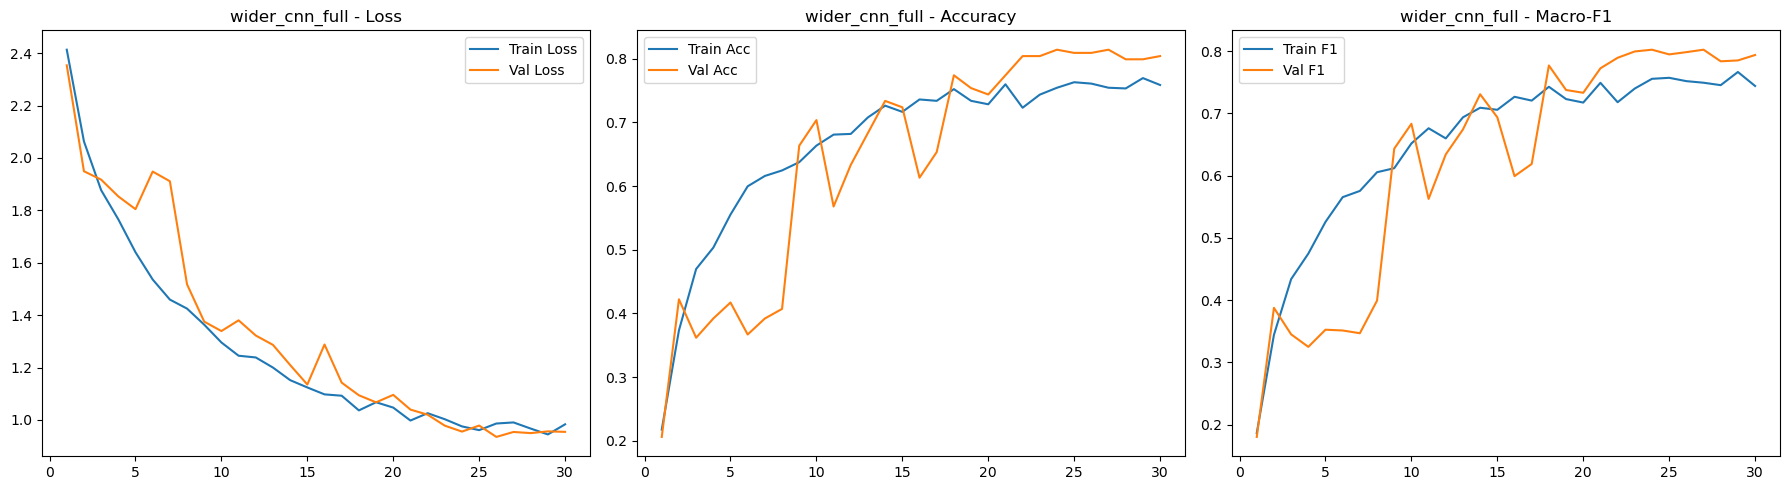

In [11]:
# CELL 10: PLOT CURVES
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title(f"{RUN_TAG} - Loss"); axes[0].legend()
axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title(f"{RUN_TAG} - Accuracy"); axes[1].legend()
axes[2].plot(epochs_range, history["train_f1"], label="Train F1")
axes[2].plot(epochs_range, history["val_f1"], label="Val F1")
axes[2].set_title(f"{RUN_TAG} - Macro-F1"); axes[2].legend()
plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=300)
plt.show()

In [12]:
# CELL 11: FINAL TEST EVAL
model.load_state_dict(torch.load(BEST_PATH))
model.eval()

sample_batch, _ = next(iter(test_loader))
sample_batch = sample_batch.to(DEVICE)
with torch.no_grad():
    start = time.time()
    for _ in range(20):
        _ = model(sample_batch)
    elapsed = time.time() - start
per_image_ms = (elapsed / (20 * sample_batch.size(0))) * 1000

test_loss, test_acc, test_f1, test_prec, test_rec = run_epoch(test_loader, train=False, desc="Final Test")
num_params = sum(p.numel() for p in model.parameters())
model_size_mb = num_params * 4 / (1024 ** 2)

results = {
    "model": "wider_cnn",
    "train_mode": "weighted_loss_ablation" if USE_WEIGHTED_LOSS else "unweighted_loss_ablation",
    "test_accuracy": test_acc, "test_macro_f1": test_f1,
    "test_precision": test_prec, "test_recall": test_rec,
    "total_params": num_params, "trainable_params": num_params,
    "model_size_mb": round(model_size_mb, 3),
    "inference_ms_per_image": round(per_image_ms, 3),
    "best_val_macro_f1": best_val_f1,
}
print(json.dumps(results, indent=2))
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

/tmp/ipykernel_17659/3063950905.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PATH))
                                            

{
  "model": "wider_cnn",
  "train_mode": "weighted_loss_ablation",
  "test_accuracy": 0.84,
  "test_macro_f1": 0.7998558711961535,
  "test_precision": 0.8139448051948053,
  "test_recall": 0.8325441919191919,
  "total_params": 375824,
  "trainable_params": 375824,
  "model_size_mb": 1.434,
  "inference_ms_per_image": 0.016,
  "best_val_macro_f1": 0.8022938689492481
}


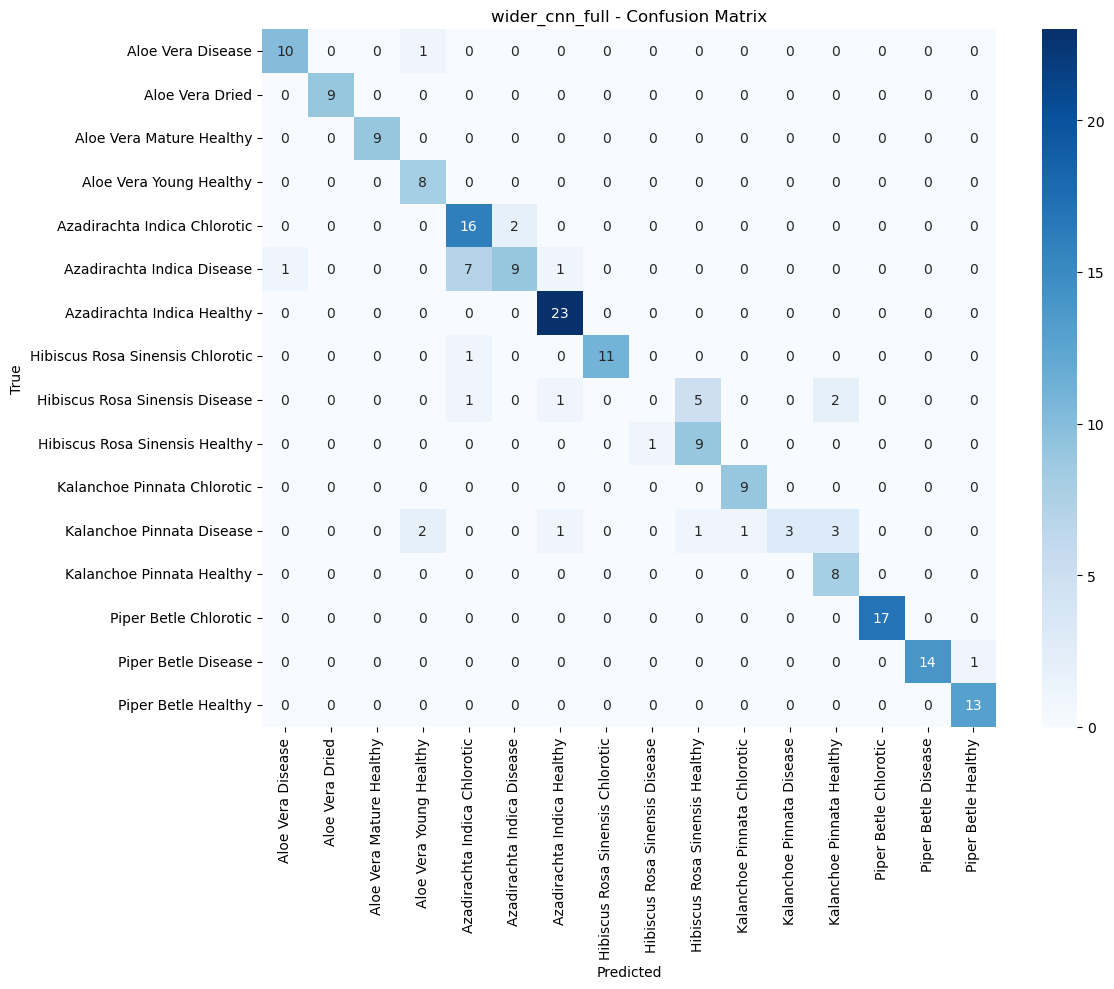

Saved confusion matrix to checkpoints/wider_cnn_full/confusion_matrix.png


In [13]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = test_ds.classes

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{RUN_TAG} - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"Saved confusion matrix to {cm_path}")